<a href="https://colab.research.google.com/github/psarya/Human-Activity-Recognition-from-Smartphone-Sensors/blob/main/code/HAR_model_and_app.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier


In [2]:
# 1.Load dataset
#----------------------------------------------
train_df=pd.read_csv("/content/train.csv")
print(train_df)

      tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  \
0              0.288585          -0.020294          -0.132905   
1              0.278419          -0.016411          -0.123520   
2              0.279653          -0.019467          -0.113462   
3              0.279174          -0.026201          -0.123283   
4              0.276629          -0.016570          -0.115362   
...                 ...                ...                ...   
7043           0.274695          -0.015287          -0.111398   
7044           0.320934          -0.014244          -0.115578   
7045           0.338288          -0.050849          -0.045762   
7046           0.318986          -0.023795          -0.089133   
7047           0.301283          -0.015003          -0.114899   

      tBodyAcc-std()-X  tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  \
0            -0.995279         -0.983111         -0.913526         -0.995112   
1            -0.998245         -0.975300         -0.960322 

In [3]:
train_df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1.0,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1.0,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1.0,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1.0,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1.0,STANDING


In [4]:
train_df.tail()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
7043,0.274695,-0.015287,-0.111398,-0.952531,-0.872289,-0.953893,-0.955734,-0.882183,-0.955993,-0.918329,...,-0.485844,0.087949,-0.316442,0.016417,0.421308,0.535192,-0.390675,-0.618448,30.0,LAYING
7044,0.320934,-0.014244,-0.115578,-0.982350,-0.934984,-0.979494,-0.983786,-0.951417,-0.980823,-0.918329,...,-0.573746,0.030780,-0.271429,0.273899,-0.550960,0.534880,-0.391863,-0.617189,30.0,LAYING
7045,0.338288,-0.050849,-0.045762,-0.921825,-0.710983,-0.848627,-0.932707,-0.728634,-0.850381,-0.818381,...,-0.360596,-0.015393,0.673681,-0.367231,0.527552,0.463108,-0.516887,-0.477618,30.0,LAYING
7046,0.318986,-0.023795,-0.089133,-0.938766,-0.891931,-0.934686,-0.943235,-0.911081,-0.942261,-0.836132,...,0.015421,-0.149003,0.807544,-0.179293,0.318064,0.449214,-0.497677,-0.495019,30.0,LAYING
7047,0.301283,-0.015003,-0.114899,-0.958518,-0.959140,-0.983687,-0.961530,-0.961907,-0.983511,-0.897537,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
train_df.columns

Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X',
       ...
       'fBodyBodyGyroJerkMag-kurtosis()', 'angle(tBodyAccMean,gravity)',
       'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'subject', 'Activity'],
      dtype='object', length=563)

In [6]:
train_df.isna().sum()

,0
tBodyAcc-mean()-X,0
tBodyAcc-mean()-Y,0
tBodyAcc-mean()-Z,0
tBodyAcc-std()-X,0
tBodyAcc-std()-Y,0
...,...
"angle(X,gravityMean)",1
"angle(Y,gravityMean)",1
"angle(Z,gravityMean)",1
subject,1


In [7]:
# 2. Data Understanding
# -----------------------------
print("\nMissing values in train:")
print(train_df.isna().sum().sum())


Missing values in train:
315


In [8]:
print("\nActivity distribution:")
print(train_df['Activity'].value_counts())


Activity distribution:
Activity
LAYING                1356
STANDING              1342
SITTING               1256
WALKING               1161
WALKING_UPSTAIRS      1008
WALKING_DOWNSTAIRS     924
Name: count, dtype: int64


In [9]:
test_df=pd.read_csv("/content/test.csv")
print(test_df)

      tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  \
0              0.257178          -0.023285          -0.014654   
1              0.286027          -0.013163          -0.119083   
2              0.275485          -0.026050          -0.118152   
3              0.270298          -0.032614          -0.117520   
4              0.274833          -0.027848          -0.129527   
...                 ...                ...                ...   
2942           0.310155          -0.053391          -0.099109   
2943           0.363385          -0.039214          -0.105915   
2944           0.349966           0.030077          -0.115788   
2945           0.237594           0.018467          -0.096499   
2946           0.153627          -0.018437          -0.137018   

      tBodyAcc-std()-X  tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  \
0            -0.938404         -0.920091         -0.667683         -0.952501   
1            -0.975415         -0.967458         -0.944958 

In [10]:
print("\nMissing values in test:")
print(test_df.isna().sum().sum())



Missing values in test:
0


In [11]:
# 3. Data Preprocessing & Cleaning
# -----------------------------
# Drop subject column because it is only participant ID
train_df = train_df.drop(columns=["subject"], errors='ignore')
test_df = test_df.drop(columns=["subject"], errors='ignore')

# Drop rows with any NaN values
train_df = train_df.dropna()
test_df = test_df.dropna()

In [12]:
X_train = train_df.drop(columns=['Activity', 'subject'], errors='ignore')
X_test = test_df.drop(columns=['Activity', 'subject'], errors='ignore')
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
y_train = train_df['Activity']
y_test = test_df['Activity']

X_train shape: (7047, 561)
X_test shape: (2947, 561)


In [13]:
# Encode target labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("\nClasses:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)


Classes:
0 -> LAYING
1 -> SITTING
2 -> STANDING
3 -> WALKING
4 -> WALKING_DOWNSTAIRS
5 -> WALKING_UPSTAIRS


In [14]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

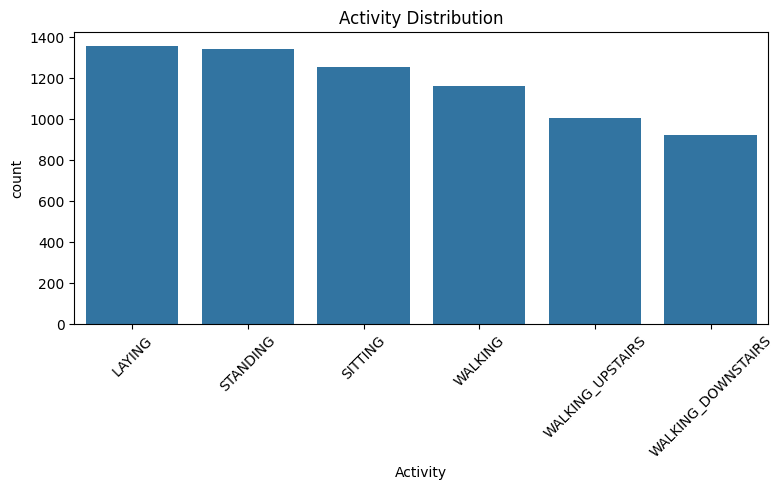

In [15]:
# 4. Exploratory Data Analysis (EDA)
# -----------------------------
plt.figure(figsize=(8, 5))
sns.countplot(x=train_df['Activity'], order=train_df['Activity'].value_counts().index)
plt.title("Activity Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

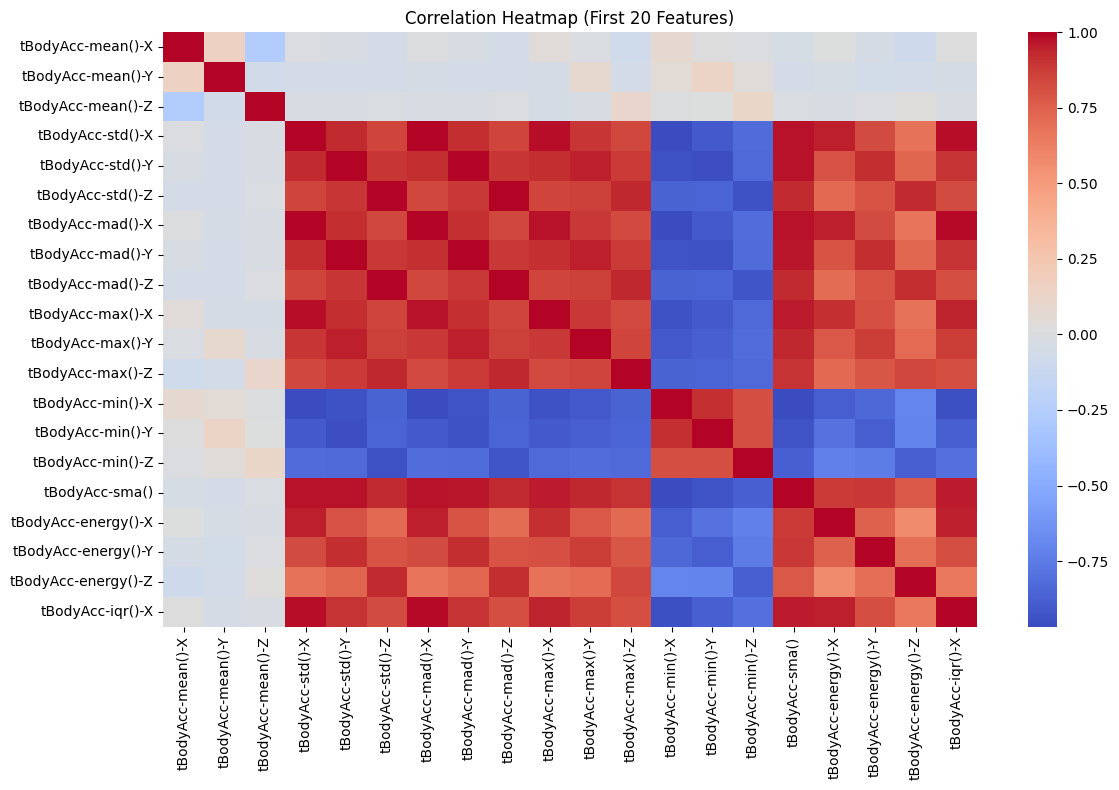

In [16]:
# Correlation heatmap for first 20 features
plt.figure(figsize=(12, 8))
sns.heatmap(train_df.drop(columns=['Activity']).iloc[:, :20].corr(), cmap='coolwarm')
plt.title("Correlation Heatmap (First 20 Features)")
plt.tight_layout()
plt.show()

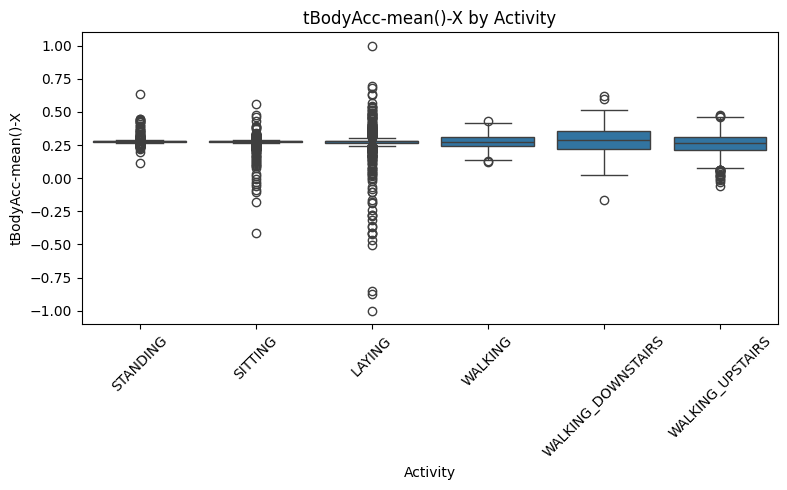

In [17]:
# Sample boxplot
sample_feature = 'tBodyAcc-mean()-X'
if sample_feature in train_df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Activity', y=sample_feature, data=train_df)
    plt.title(f"{sample_feature} by Activity")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [18]:
# 5. Feature Engineering & Selection
# -----------------------------
selector = SelectKBest(score_func=f_classif, k=50)
X_train_selected = selector.fit_transform(X_train_scaled, y_train_encoded)
X_test_selected = selector.transform(X_test_scaled)

selected_features = X_train.columns[selector.get_support()]
print("\nTop selected features:")
print(selected_features.tolist())




Top selected features:
['tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-mad()-X', 'tBodyAcc-max()-X', 'tBodyAcc-sma()', 'tGravityAcc-mean()-X', 'tGravityAcc-max()-X', 'tGravityAcc-min()-X', 'tGravityAcc-energy()-X', 'tBodyAccJerk-std()-X', 'tBodyAccJerk-mad()-X', 'tBodyAccJerk-sma()', 'tBodyAccJerk-entropy()-X', 'tBodyAccJerk-entropy()-Y', 'tBodyAccJerk-entropy()-Z', 'tBodyGyroJerk-entropy()-Z', 'tBodyAccMag-mean()', 'tBodyAccMag-max()', 'tBodyAccMag-sma()', 'tGravityAccMag-mean()', 'tGravityAccMag-max()', 'tGravityAccMag-sma()', 'tBodyAccJerkMag-mean()', 'tBodyAccJerkMag-std()', 'tBodyAccJerkMag-mad()', 'tBodyAccJerkMag-sma()', 'tBodyAccJerkMag-iqr()', 'tBodyAccJerkMag-entropy()', 'fBodyAcc-mean()-X', 'fBodyAcc-mean()-Y', 'fBodyAcc-std()-X', 'fBodyAcc-mad()-X', 'fBodyAcc-mad()-Y', 'fBodyAcc-sma()', 'fBodyAcc-entropy()-X', 'fBodyAcc-entropy()-Y', 'fBodyAcc-entropy()-Z', 'fBodyAccJerk-mean()-X', 'fBodyAccJerk-std()-X', 'fBodyAccJerk-mad()-X', 'fBodyAccJerk-sma()', 'fBodyAccJerk-entro

In [19]:
# 6. Model Building & Training
# -----------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = {}

for name, model in models.items():
    model.fit(X_train_selected, y_train_encoded)
    y_pred = model.predict(X_test_selected)
    acc = accuracy_score(y_test_encoded, y_pred)

    results[name] = {
        "model": model,
        "accuracy": acc,
        "predictions": y_pred
    }

    print(f"\n{name} Accuracy: {acc:.4f}")


Logistic Regression Accuracy: 0.8914

Decision Tree Accuracy: 0.8079

Random Forest Accuracy: 0.8487

KNN Accuracy: 0.8320



Model Comparison:
                 Model  Accuracy
0  Logistic Regression  0.891415
2        Random Forest  0.848660
3                  KNN  0.832033
1        Decision Tree  0.807940


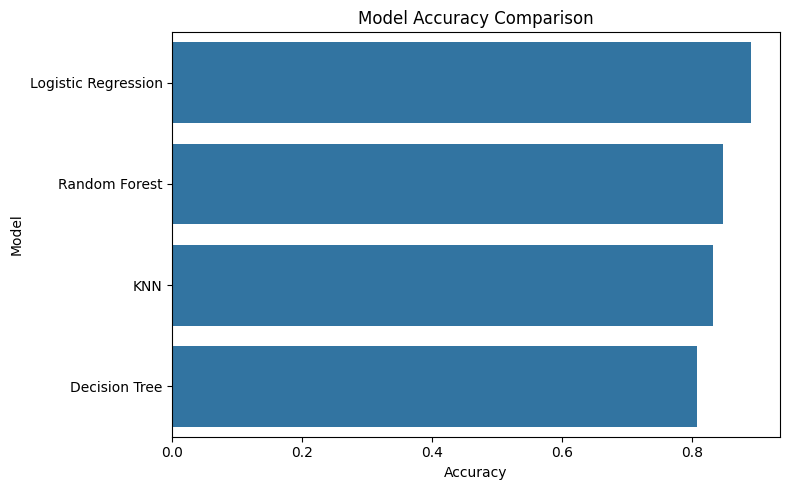


Best Model: Logistic Regression

Classification Report:
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.84      0.68      0.75       491
          STANDING       0.75      0.88      0.81       532
           WALKING       0.86      0.98      0.92       496
WALKING_DOWNSTAIRS       0.98      0.93      0.95       420
  WALKING_UPSTAIRS       0.96      0.87      0.91       471

          accuracy                           0.89      2947
         macro avg       0.90      0.89      0.89      2947
      weighted avg       0.90      0.89      0.89      2947



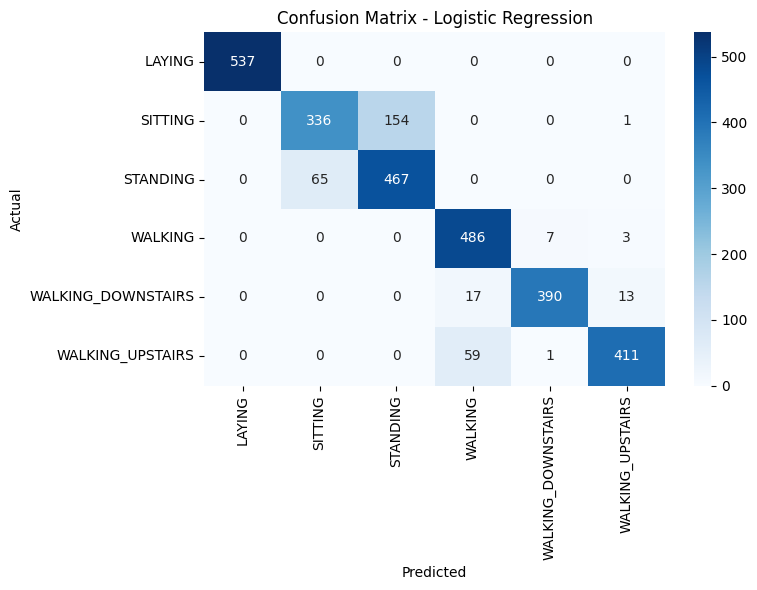

In [20]:
# 7. Model Evaluation & Comparison
# -----------------------------
results_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [results[m]["accuracy"] for m in results]
}).sort_values(by="Accuracy", ascending=False)

print("\nModel Comparison:")
print(results_df)

plt.figure(figsize=(8, 5))
sns.barplot(x="Accuracy", y="Model", data=results_df)
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]["Model"]
best_model = results[best_model_name]["model"]
best_preds = results[best_model_name]["predictions"]

print(f"\nBest Model: {best_model_name}")

print("\nClassification Report:")
print(classification_report(y_test_encoded, best_preds, target_names=label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_test_encoded, best_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [21]:
# 8. Model Interpretation & Explainability
# -----------------------------
if best_model_name == "Random Forest":
    feature_importance_df = pd.DataFrame({
        "Feature": selected_features,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    print("\nTop 15 Important Features:")
    print(feature_importance_df.head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(x="Importance", y="Feature", data=feature_importance_df.head(15))
    plt.title("Top 15 Feature Importances")
    plt.tight_layout()
    plt.show()


In [22]:
# 10. Predict one sample
# -----------------------------
def predict_activity(sample_row_df):
    sample_scaled = scaler.transform(sample_row_df)
    sample_selected = selector.transform(sample_scaled)
    pred = best_model.predict(sample_selected)
    return label_encoder.inverse_transform(pred)[0]

example_sample = X_test.iloc[[0]]
predicted = predict_activity(example_sample)

print("\nExample Prediction:", predicted)
print("Actual Activity:", y_test.iloc[0])


Example Prediction: STANDING
Actual Activity: STANDING


In [23]:
#save model
import pickle
with open('model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

In [24]:
import pickle

pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(selector, open("selector.pkl", "wb"))
pickle.dump(label_encoder, open("label_encoder.pkl", "wb"))

In [25]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle

# Page Config
st.set_page_config(page_title="HAR Predictor", layout="wide")
st.title("🏃 Human Activity Recognition")
st.write("Predict physical activity based on smartphone sensor data.")

# 1. Load Pre-trained Objects
@st.cache_resource
def load_assets():
    model = pickle.load(open("model.pkl", "rb"))
    scaler = pickle.load(open("scaler.pkl", "rb"))
    selector = pickle.load(open("selector.pkl", "rb"))
    label_encoder = pickle.load(open("label_encoder.pkl", "rb"))
    return model, scaler, selector, label_encoder

try:
    model, scaler, selector, label_encoder = load_assets()

    # 2. File Upload Section
    st.sidebar.header("Data Input")
    uploaded_file = st.sidebar.file_uploader("Upload sensor CSV", type=["csv"])

    if uploaded_file is not None:
        # ✅ FIX: read uploaded file instead of hardcoded path
        test_df = pd.read_csv(uploaded_file)

        st.subheader("Raw Data Preview")
        st.dataframe(test_df.head())

        # Preprocessing
        proc_df = test_df.drop(columns=["subject", "Activity"], errors="ignore")

        if st.button("🚀 Predict Activities"):
            scaled_data = scaler.transform(proc_df)
            selected_data = selector.transform(scaled_data)
            preds = model.predict(selected_data)
            labels = label_encoder.inverse_transform(preds)

            result_df = test_df.copy()
            result_df["Predicted_Activity"] = labels

            st.subheader("Prediction Results")
            st.dataframe(result_df[["Predicted_Activity"] + list(proc_df.columns[:3])].head(20))

            csv = result_df.to_csv(index=False).encode('utf-8')
            st.download_button("📥 Download Results", csv, "predictions.csv", "text/csv")

    # 3. Manual Demo Section
    st.divider()
    st.subheader("Manual Prediction Demo")
    st.info("Simulate a prediction using one random row from uploaded data.")

    # ✅ FIX: correct indentation + remove undefined variables
    if st.button("Simulate Random Activity"):
        if uploaded_file is not None:
            sample = proc_df.sample(1)

            sample_scaled = scaler.transform(sample)
            sample_selected = selector.transform(sample_scaled)

            pred = model.predict(sample_selected)
            result = label_encoder.inverse_transform(pred)[0]

            st.success(f"Predicted Activity: {result}")
        else:
            st.warning("Please upload a dataset first.")

except FileNotFoundError:
    st.error("Missing files! Ensure model.pkl, scaler.pkl, selector.pkl, and label_encoder.pkl are available.")

Writing app.py


In [26]:
# 1. Install dependencies
!pip install streamlit pyngrok

# 2. Import libraries
from pyngrok import ngrok
import time

# 2.1. Set ngrok authtoken (replace 'YOUR_AUTHTOKEN' with your actual token)
# Get your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token('3CbpPHUbhmRVBfihdqBxQeQKecC_6Ywhh54t8LKUd7abcDTtT')

# 3. Kill any existing tunnels (important)
ngrok.kill()

# 4. Start Streamlit in background
get_ipython().system_raw('streamlit run app.py --server.port 8501 &')

# 5. Wait for Streamlit to start
time.sleep(10)

# 6. Create public URL
public_url = ngrok.connect(8501)
print("🚀 Your Streamlit App is Live at:")
print(public_url)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 91.4 MB/s eta 0:00:00
🚀 Your Streamlit App is Live at:
NgrokTunnel: "https://wheat-amiable-impotent.ngrok-free.dev" -> "http://localhost:8501"
